# Робота з даними про автомобілі (Auto MPG)


Ініціалізуємо необхідні бібліотеки.

In [2]:
import os
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates

Завантажимо zip-архів з датасетом

In [3]:
def download_file():
    os.makedirs("data", exist_ok=True)

    url = "https://archive.ics.uci.edu/static/public/9/auto+mpg.zip"
    zip_path = "data/auto+mpg.zip"
    extract_path = "data/auto_mpg"

    if not os.path.isdir(extract_path):
        os.makedirs(extract_path, exist_ok=True)
        if not os.path.isfile(zip_path):
            response = requests.get(url)
            with open(zip_path, "wb") as file:
                file.write(response.content)
            print("Файл було успішно завантажено з серверу")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_path)
            print("Архів з даними було успішно розпаковано")
    else:
        print("Файл буде прочитано з диску")

download_file()

Файл було успішно завантажено з серверу
Архів з даними було успішно розпаковано


Створимо DataFrame з файлу та здійснимо Data Cleaning

In [4]:
def csv_to_df(data_file):
    columns = [
        "mpg", "cylinders", "displacement", "horsepower", "weight",
        "acceleration", "model_year", "origin", "car_name"
    ]

    df = pd.read_csv(data_file, sep=r"\s+", header=None, names=columns, na_values="?")

    df.dropna(inplace=True)

    numeric_cols = ["mpg", "displacement", "horsepower", "weight", "acceleration"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["origin"] = df["origin"].map({1: "USA", 2: "Europe", 3: "Japan"})

    df.drop(columns=["car_name"], inplace=True)

    return df

df_mpg = csv_to_df("data/auto_mpg/auto-mpg.data")

print(f"Кількість записів: {len(df_mpg)}, кількість стовпців: {len(df_mpg.columns)}")
df_mpg.info()
df_mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA


Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).

Для візуалізації залежності витрати пального від ваги автомобіля я обрав scatterplot, оскільки цей тип графіка найкраще підходить для відображення зв'язку між двома кількісними змінними, віін дозволяє показати кожне окреме спостереження у вигляді точки на площині, що дає змогу оцінити загальну тенденцію, щільність розподілу даних, варіативність показників та можливі викиди, з інженерної точки зору такий графік дозволяє простежити, як із збільшенням ваги автомобіля зростає витрата пального, що єпрямим наслідком збільшення інерційного навантаження на двигун

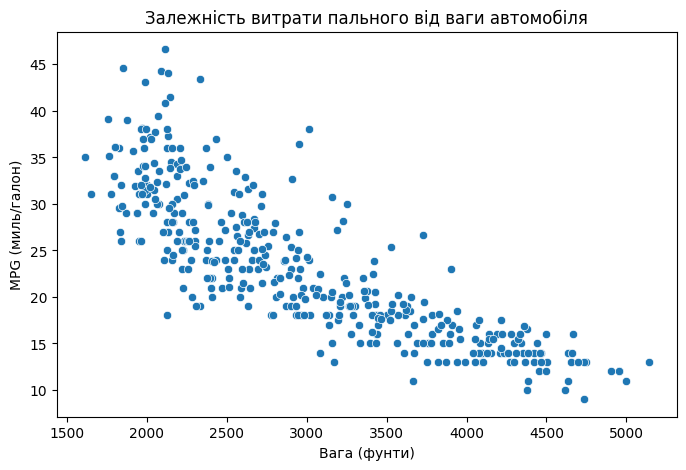

In [5]:
def scatterplot():
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_mpg, x='weight', y='mpg')
    plt.title('Залежність витрати пального від ваги автомобіля')
    plt.xlabel('Вага (фунти)')
    plt.ylabel('MPG (миль/галон)')
    plt.show()

scatterplot()

Для візуалізації зміни середнього показника витрати пального з роками я обрав lineplot, оскільки цей тип графіка добре підходить для відображення тренду числового показника вздовж впорядкованої змінної - у цьому випадку середнього значення mpg для кожного модельного року. Лінійний графік дозволяє простежити загальну тенденцію та коливання показника між роками. З інженерної точки зору такий аналіз демонструє, як із часом виробники покращували паливну ефективність автомобілів.

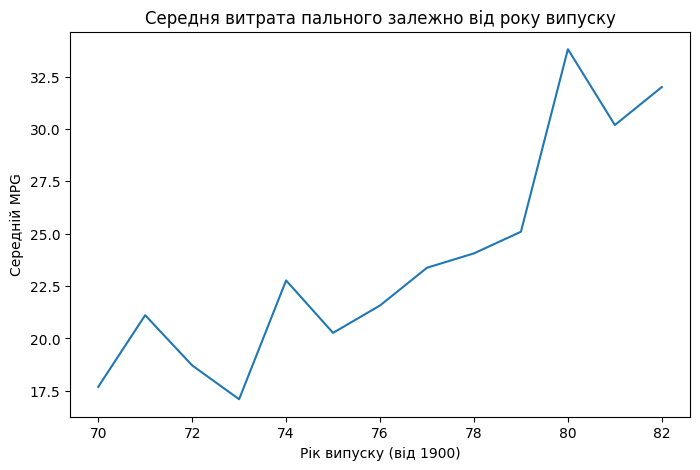

In [6]:
def lineplot():
    mean_mpg_by_year = df_mpg.groupby('model_year')['mpg'].mean().reset_index()

    plt.figure(figsize=(8, 5))
    sns.lineplot(data=mean_mpg_by_year, x='model_year', y='mpg')
    plt.title('Середня витрата пального залежно від року випуску')
    plt.xlabel('Рік випуску (від 1900)')
    plt.ylabel('Середній MPG')
    plt.show()

lineplot()

Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.

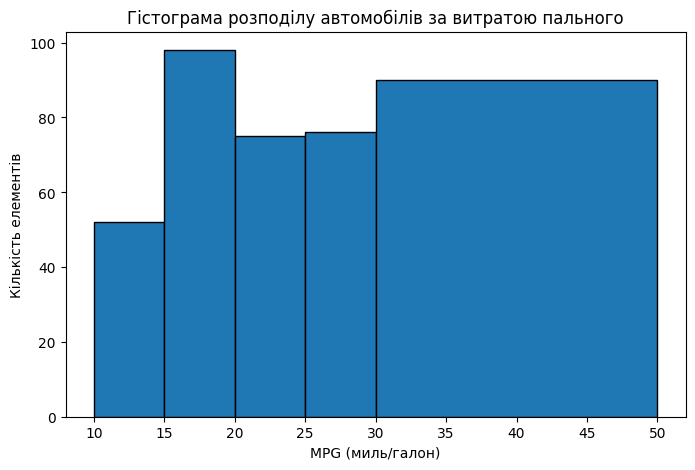

In [7]:
def hist_by_bins():
    bins = list(map(int, input("Введіть 6 значень діапазонів (у форматі: 10 15 20 25 30 50): ").split()))

    plt.figure(figsize=(8, 5))
    plt.hist(df_mpg['mpg'].dropna(), bins=bins, edgecolor='black')
    plt.title('Гістограма розподілу автомобілів за витратою пального')
    plt.xlabel('MPG (миль/галон)')
    plt.ylabel('Кількість елементів')
    plt.show()

hist_by_bins()

збудувати графіки використовуючи приклади

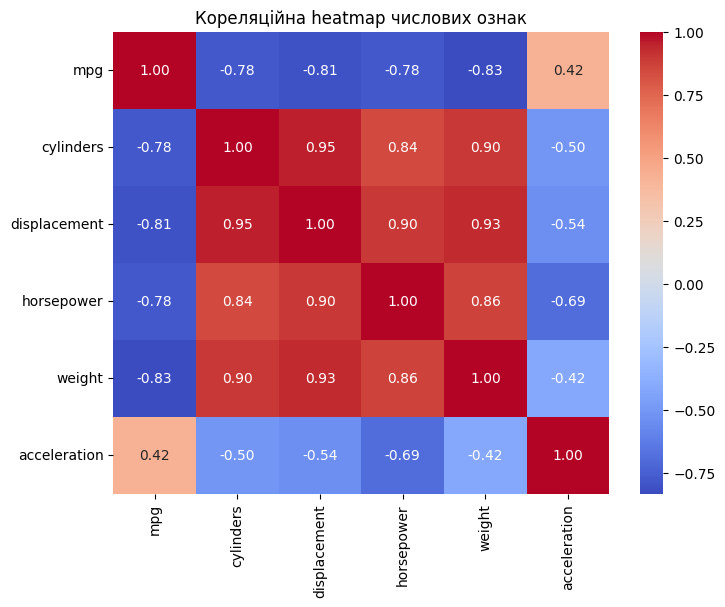

In [8]:
def heatmap():
    num_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
    corr = df_mpg[num_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Кореляційна heatmap числових ознак')
    plt.show()

heatmap()

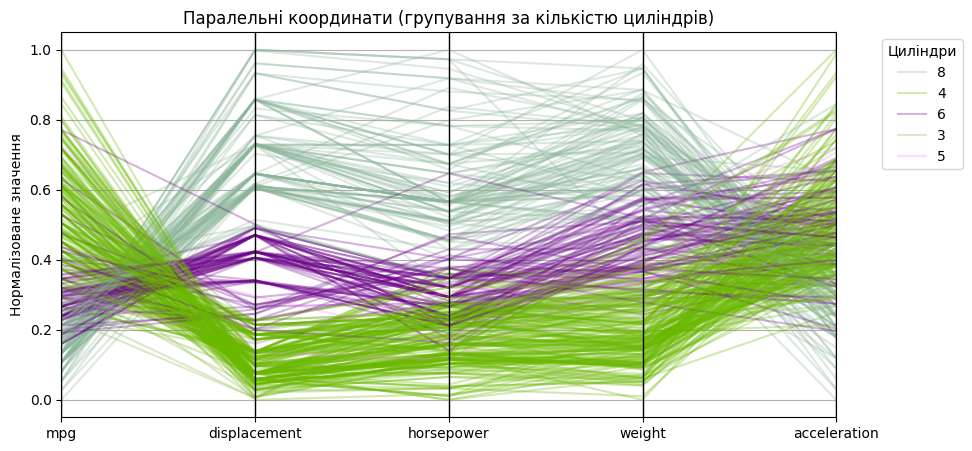

In [9]:
def parallel_coords():
    cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration', 'cylinders']
    df_p = df_mpg[cols].copy()

    for col in ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']:
        df_p[col] = (df_p[col] - df_p[col].min()) / (df_p[col].max() - df_p[col].min())

    df_p['cylinders'] = df_p['cylinders'].astype(str)

    plt.figure(figsize=(10, 5))
    parallel_coordinates(df_p, 'cylinders', alpha=0.3)
    plt.title('Паралельні координати (групування за кількістю циліндрів)')
    plt.ylabel('Нормалізоване значення')
    plt.legend(title='Циліндри', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

parallel_coords()

Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.

Для візуалізації розподілу потужності двигуна залежно від регіону виробника я обрав violinplot, оскільки цей тип графіка ефективно відображає форму розподілу числової змінної horsepower у межах категоріальної ознаки origin. Він поєднує в собі переваги boxplot і KDE-графіка: дозволяє побачити медіану, міжквартильний розмах і щільність розподілу одночасно. З інженерної точки зору це дає змогу порівняти, чи відрізняється характеристика потужності у автомобілів різних регіонів.

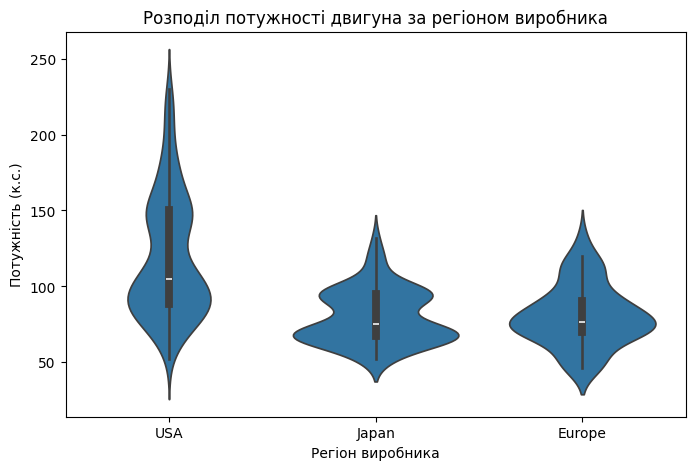

In [10]:
def violinplot():
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df_mpg, x='origin', y='horsepower')
    plt.title('Розподіл потужності двигуна за регіоном виробника')
    plt.xlabel('Регіон виробника')
    plt.ylabel('Потужність (к.с.)')
    plt.show()

violinplot()

Для візуалізації розподілу витрати пального залежно від кількості циліндрів я обрав boxplot, оскільки цей тип графіка ефективно відображає розподіл числової змінної mpg у межах категоріальної ознаки cylinders. Він дозволяє порівняти медіану, міжквартильний розмах, загальний розкид та можливі викиди між групами. З технічної точки зору така візуалізація демонструє, як кількість циліндрів безпосередньо впливає на паливну ефективність автомобіля.

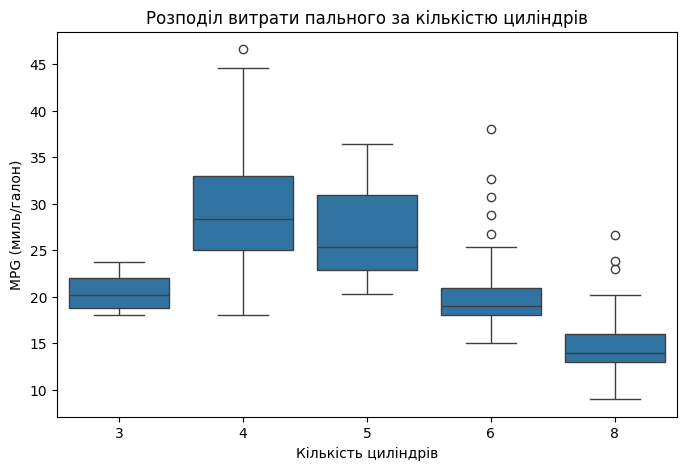

In [11]:
def boxplot():
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_mpg, x='cylinders', y='mpg')
    plt.title('Розподіл витрати пального за кількістю циліндрів')
    plt.xlabel('Кількість циліндрів')
    plt.ylabel('MPG (миль/галон)')
    plt.show()

boxplot()

Для багатовимірного аналізу було використано pairplot, цей тип графіка дозволяє одночасно показати попарні зв'язки між кількома числовими ознаками та їх розподіл. У контексті автомобільних даних це дає змогу порівняти, як показники (mpg, horsepower, weight, acceleration) пов'язані між собою та чи відрізняються ці зв'язки залежно від регіону виробника автомобіля.

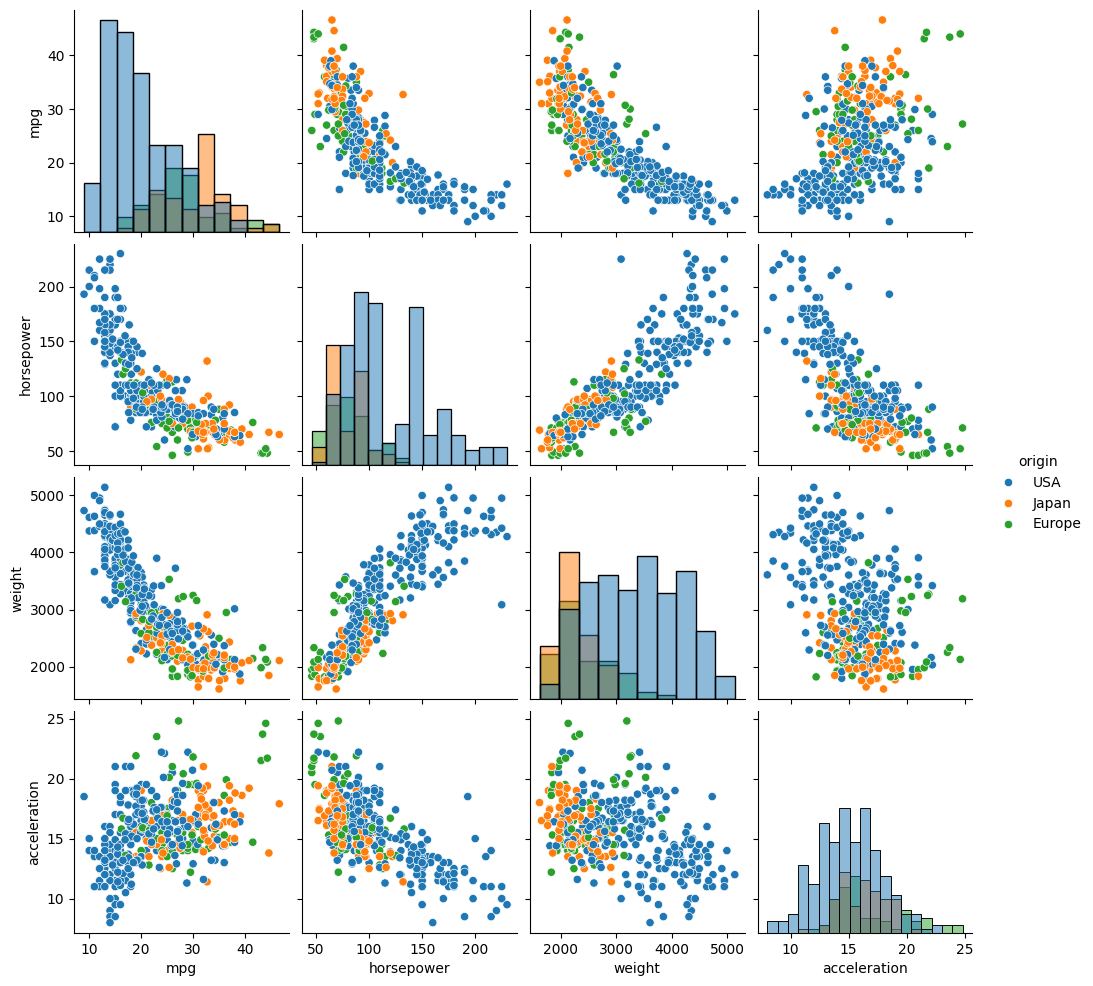

In [12]:
def pairplot():
    df_pair = df_mpg[['mpg', 'horsepower', 'weight', 'acceleration', 'origin']].copy()

    sns.pairplot(
        df_pair,
        vars=['mpg', 'horsepower', 'weight', 'acceleration'],
        hue='origin',
        diag_kind='hist'
    )

    plt.show()

pairplot()

Для відображення розподілу автомобілів за кількістю циліндрів я обрав pie chart, оскільки цей тип графіка найкраще підходить для відображення часток цілого. Він дозволяє наочно побачити, яка частка автомобілів у датасеті має 4, 6 або 8 циліндрів, що дає загальне уявлення про структуру вибірки.

In [ ]:
def piechart():
    counts = df_mpg['cylinders'].value_counts().sort_index()

    plt.figure(figsize=(7, 7))
    plt.pie(
        counts.values,
        labels=[f'{int(c)} цил.' for c in counts.index],
        autopct='%1.1f%%',
        startangle=140
    )
    plt.title('Розподіл автомобілів за кількістю циліндрів')
    plt.show()

piechart()